In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize 
import matplotlib.gridspec as gridspec
from sharedfunctions import loadKernels, computeSigma, computeMagnitudeResponse, \
    calculateEcc, eccL2Distance, eccWassersteinDistance, \
    IDXROBUST, IDXVULNERABLE, GRIDSIZE, SIGMAGRID, NTHRESH, CSVPATH

In [2]:
kernels = loadKernels(CSVPATH)

In [3]:
def fsgmPerturbation(h, epsilon= 0.05):
    mag = computeMagnitudeResponse(h, grid = GRIDSIZE)
    flatidx = np.argsort(mag.ravel())[:20]
    rows, cols = np.unravel_index(flatidx, mag.shape)
    Hperturbed = np.zeros((GRIDSIZE, GRIDSIZE), dtype=complex)
    for r, c in zip(rows, cols):
        Hperturbed[r, c] = epsilon * GRIDSIZE**2
    perturbFull = np.real(np.fft.ifft2(np.fft.ifftshift(Hperturbed)))
    centre = GRIDSIZE // 2
    perturb3x3 = perturbFull[centre-1:centre+2, centre-1:centre+2]
    return h + perturb3x3, perturb3x3

In [4]:
epsilons = [0.01, 0.05, 0.1, 0.2, 0.3]
for idx, label in [(IDXROBUST, "Robust"), (IDXVULNERABLE, "Vulnerable")]:
    hclean = kernels[idx]
    sigmac = computeSigma(hclean)
    print(f"\n--- {label} Kernel (idx={idx}) ---")

    for epsilon in epsilons:
        hp, _ = fsgmPerturbation(hclean, epsilon=epsilon)
        s = computeSigma(hp)
        change = ((s - sigmac) / (sigmac + 1e-22)) * 100

        print(f" epsilon = {epsilon:.2f} | sigma={s:.6f} (change: {change:+.1f}%)")



--- Robust Kernel (idx=3503) ---
 epsilon = 0.01 | sigma=0.893179 (change: -8.7%)
 epsilon = 0.05 | sigma=0.060736 (change: -93.8%)
 epsilon = 0.10 | sigma=0.049596 (change: -94.9%)
 epsilon = 0.20 | sigma=0.009876 (change: -99.0%)
 epsilon = 0.30 | sigma=0.043654 (change: -95.5%)

--- Vulnerable Kernel (idx=2905) ---
 epsilon = 0.01 | sigma=0.000852 (change: +294011.3%)
 epsilon = 0.05 | sigma=0.005829 (change: +2012640.4%)
 epsilon = 0.10 | sigma=0.018852 (change: +6509460.7%)
 epsilon = 0.20 | sigma=0.023184 (change: +8005247.3%)
 epsilon = 0.30 | sigma=0.007292 (change: +2517620.2%)


/var/folders/85/3hlfymdd0mg01kbks_s9w5mc0000gn/T/ipykernel_17626/4238351712.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1800x1200 with 0 Axes>

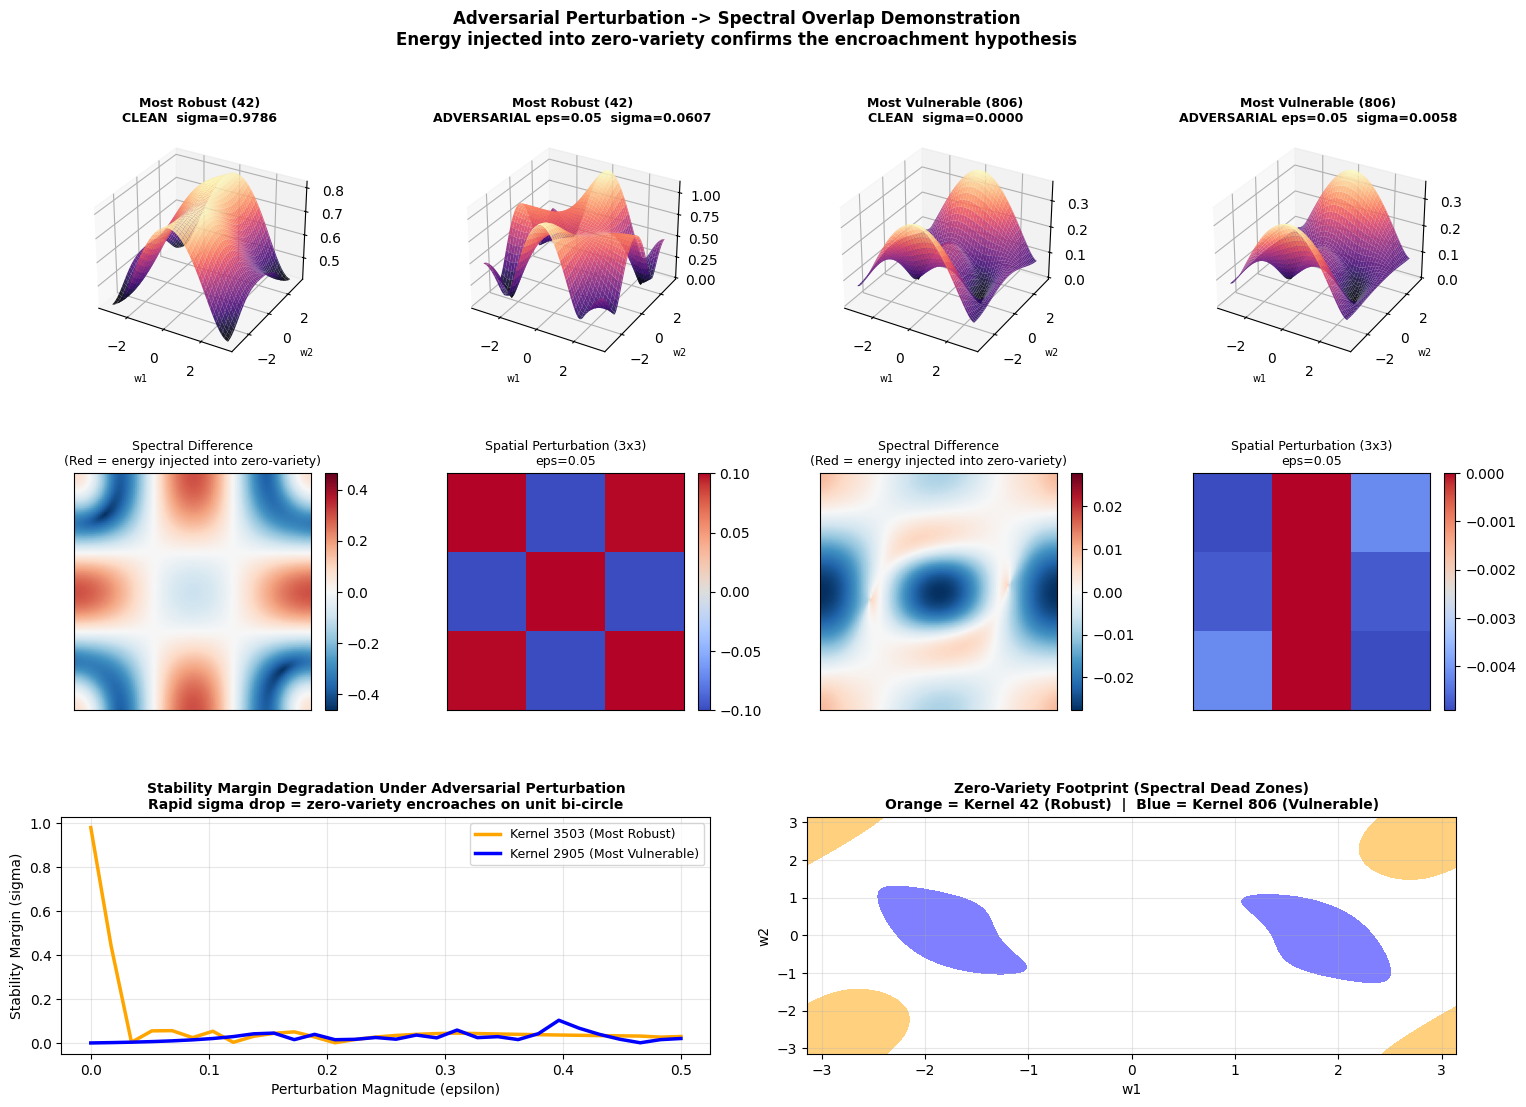

In [ ]:
omega = np.linspace(-np.pi, np.pi, GRIDSIZE)
W1, W2 = np.meshgrid(omega, omega)

fig = plt.figure(figsize=(18, 12))
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Adversarial Perturbation -> Spectral Overlap Demonstration\n"
             "Energy injected into zero-variety confirms the encroachment hypothesis",
             fontsize=12, fontweight='bold')

gs = fig.add_gridspec(3, 4, hspace=0.45, wspace=0.35)  # ADD THIS LINE
fig.suptitle("Adversarial Perturbation -> Spectral Overlap Demonstration\n" "Energy injected into zero-variety confirms the encroachment hypothesis", fontsize=12, fontweight='bold')
configs = [(IDXROBUST, f"Most Robust ({IDXROBUST})", 0.05, "orange"),
           (IDXVULNERABLE, f"Most Vulnerable ({IDXVULNERABLE})", 0.05, "blue")]
for col, (idx, label, epsilon, color) in enumerate(configs):
    hclean = kernels[idx]
    hperturbed, perturbation = fsgmPerturbation(hclean, epsilon=epsilon)
    magClean = computeMagnitudeResponse(hclean)
    magPerturbed = computeMagnitudeResponse(hperturbed)
    magDiff = magPerturbed - magClean
    sigmac = computeSigma(hclean)
    sigmap = computeSigma(hperturbed)

    ax1 = fig.add_subplot(gs[0, col*2], projection='3d')
    ax1.plot_surface(W1, W2, magClean, cmap='magma', edgecolor='none', alpha = 0.9)
    ax1.set_title(f"{label}\nCLEAN  sigma={sigmac:.4f}", fontsize=9, fontweight='bold')
    ax1.set_xlabel("w1", fontsize=7); ax1.set_ylabel("w2", fontsize=7)

    ax2 = fig.add_subplot(gs[0, col*2 + 1], projection='3d')
    ax2.plot_surface(W1, W2, magPerturbed, cmap='magma', edgecolor='none', alpha=0.9)
    ax2.set_title(f"{label}\nADVERSARIAL eps={epsilon}  sigma={sigmap:.4f}",
                  fontsize=9, fontweight='bold')
    ax2.set_xlabel("w1", fontsize=7); ax2.set_ylabel("w2", fontsize=7)


    ax3 = fig.add_subplot(gs[1, col*2])
    vmax = np.max(np.abs(magDiff))
    im = ax3.imshow(magDiff, cmap='RdBu_r', norm=Normalize(vmin=-vmax, vmax=vmax))
    ax3.set_title("Spectral Difference\n(Red = energy injected into zero-variety)", fontsize=9)
    plt.colorbar(im, ax=ax3, fraction=0.046)
    ax3.set_xticks([]); ax3.set_yticks([])


    ax4 = fig.add_subplot(gs[1, col*2 + 1])
    im2 = ax4.imshow(perturbation, cmap='coolwarm')
    ax4.set_title(f"Spatial Perturbation (3x3)\neps={epsilon}", fontsize=9)
    plt.colorbar(im2, ax=ax4, fraction=0.046)
    ax4.set_xticks([]); ax4.set_yticks([])

ax5 = fig.add_subplot(gs[2, :2])
epsFine = np.linspace(0, 0.5, 30)
for idx, label, color in [(IDXROBUST,     f"Kernel {IDXROBUST} (Most Robust)",      "orange"),
                           (IDXVULNERABLE, f"Kernel {IDXVULNERABLE} (Most Vulnerable)", "blue")]:
    hClean = kernels[idx]
    sigsEps = [computeSigma(fsgmPerturbation(hClean, epsilon)[0]) for epsilon in epsFine]
    ax5.plot(epsFine, sigsEps, color=color, linewidth=2.5, label=label)
ax5.set_title("Stability Margin Degradation Under Adversarial Perturbation\n"
              "Rapid sigma drop = zero-variety encroaches on unit bi-circle",
              fontsize=10, fontweight='bold')
ax5.set_xlabel("Perturbation Magnitude (epsilon)", fontsize=10)
ax5.set_ylabel("Stability Margin (sigma)", fontsize=10)
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(gs[2, 2:])
magRob = computeMagnitudeResponse(kernels[IDXROBUST])
magVul = computeMagnitudeResponse(kernels[IDXVULNERABLE])
threshRob = np.percentile(magRob, 10)
threshVul = np.percentile(magVul, 10)
ax6.contourf(W1, W2, magRob, levels=[0, threshRob], colors=['orange'], alpha=0.5)
ax6.contourf(W1, W2, magVul, levels=[0, threshVul], colors=['blue'],   alpha=0.5)
ax6.set_title("Zero-Variety Footprint (Spectral Dead Zones)\n"
              "Orange = Kernel 42 (Robust)  |  Blue = Kernel 806 (Vulnerable)",
              fontsize=10, fontweight='bold')
ax6.set_xlabel("w1", fontsize=10); ax6.set_ylabel("w2", fontsize=10)
ax6.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig("AdversarialSpectralOverlap.png", dpi=150, bbox_inches='tight')
plt.show()

